In [5]:
!pip install numpy matplotlib

In [15]:
import sys
!{sys.executable} -m pip install scikit-learn

   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   -------- ------------------------------- 1.8/8.7 MB 9.0 MB/s eta 0:00:01
   ------------------ --------------------- 3.9/8.7 MB 9.2 MB/s eta 0:00:01
   -------------------------- ------------- 5.8/8.7 MB 9.3 MB/s eta 0:00:01
   ------------------------------------ --- 7.9/8.7 MB 9.4 MB/s eta 0:00:01
   ---------------------------------------- 8.7/8.7 MB 8.8 MB/s  0:00:00
   ---------------------------------------- 0.0/38.5 MB ? eta -:--:--
   - -------------------------------------- 1.8/38.5 MB 9.1 MB/s eta 0:00:05
   --- ------------------------------------ 3.7/38.5 MB 9.3 MB/s eta 0:00:04
   ----- ---------------------------------- 5.8/38.5 MB 9.4 MB/s eta 0:00:04
   -------- ------------------------------- 7.9/38.5 MB 9.5 MB/s eta 0:00:04
   ---------- ----------------------------- 9.7/38.5 MB 9.5 MB/s eta 0:00:04
   ------------ --------------------------- 11.8/38.5 MB 9.5 MB/s eta 0:00:03
   -------------- ---

In [22]:
import sys
!{sys.executable} -m pip install kneed

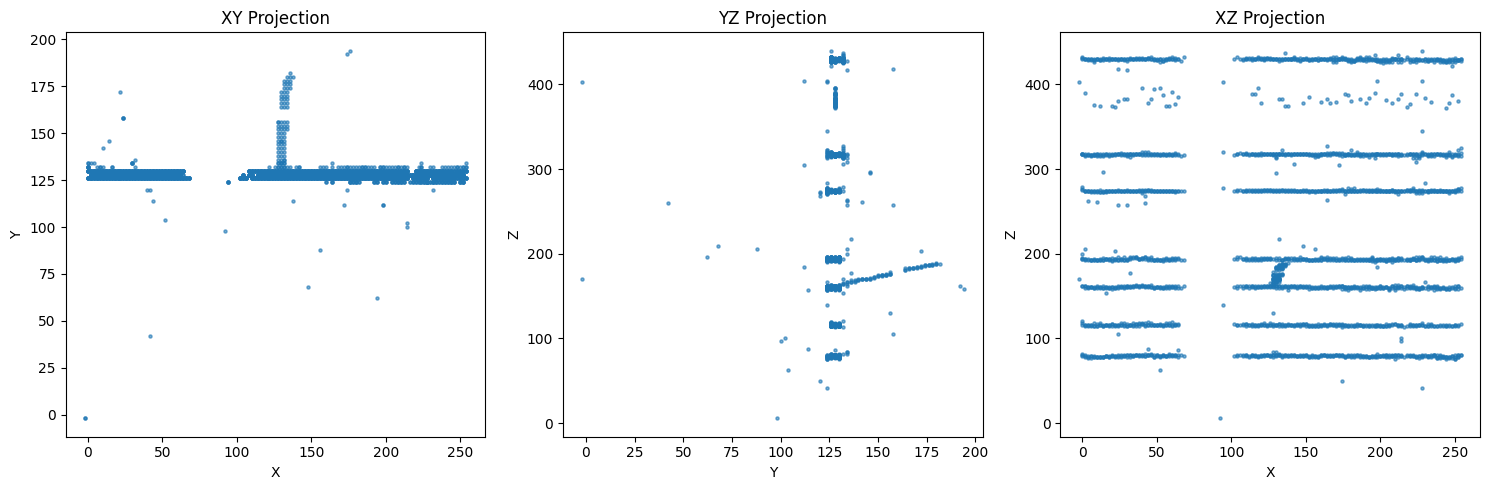

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data
data = np.load('exp_event_34_run_53.npy')

# Extract coordinates
x = data[:, 0]
y = data[:, 1]
z = data[:, 2]

# Create subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# XY projection
axs[0].scatter(x, y, s=5, alpha=0.6)
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[0].set_title('XY Projection')

# YZ projection
axs[1].scatter(y, z, s=5, alpha=0.6)
axs[1].set_xlabel('Y')
axs[1].set_ylabel('Z')
axs[1].set_title('YZ Projection')

# XZ projection
axs[2].scatter(x, z, s=5, alpha=0.6)
axs[2].set_xlabel('X')
axs[2].set_ylabel('Z')
axs[2].set_title('XZ Projection')

plt.tight_layout()
plt.show()

In [24]:
# Function to find DBSCAN Clusters
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator
from sklearn.cluster import DBSCAN
def dbcluster(data_array, N_PROC, nn_neighbor, nn_radius, db_min_samples, sensitivity_, eps_threshold_, eps_mode_):
    """
    Perform DBSCAN clustering on a given data array with adaptive epsilon calculation.

    Parameters:
    - data_array: np.ndarray
        Input data with at least 3 columns (x, y, z).
    - N_PROC: int
        Number of processes for parallel computation.
    - nn_neighbor: int
        Number of nearest neighbors for the NearestNeighbors algorithm.
    - nn_radius: float
        Radius for the NearestNeighbors algorithm.
    - db_min_samples: int
        Minimum samples for a cluster in DBSCAN.
    - sensitivity_: float
        Sensitivity for the KneeLocator.
    - eps_threshold_: float
        Threshold below which epsilon defaults to eps_mode_.
    - eps_mode_: float
        Default epsilon value if calculated epsilon is below threshold.

    Returns:
    - labels_: np.ndarray
        Cluster labels from DBSCAN or [-1, -1] in case of failure.
    - valid_cluster: bool
        True if clustering is successful, False otherwise.
    - epsilon_: float
        The epsilon value used for DBSCAN.
    """
    valid_cluster = True
    epsilon_ = 0  # Default epsilon value
    try:
        # Extract the first three columns (x, y, z)
        extractedData = data_array[:, 0:2 + 1]

        # Nearest neighbors setup
        neigh = NearestNeighbors(n_neighbors=nn_neighbor, radius=nn_radius)
        nbrs = neigh.fit(extractedData)
        distances, indices = nbrs.kneighbors(extractedData)
        distances = np.sort(distances, axis=0)
        dist_ = distances[:, nn_neighbor-1]

        # KneeLocator to find the optimal epsilon
        kneedle = KneeLocator(
            x=indices[:, 0],
            y=dist_,
            S=sensitivity_,
            curve='convex',
            direction='increasing',
            interp_method='interp1d'
        )
        if kneedle.knee is None:
            raise ValueError("KneeLocator failed to identify a knee point.")

        epsilon_ = round(dist_[int(kneedle.knee)], 2)
        if epsilon_ < eps_threshold_:
            print('EPSILON BELOW THRESHOLD, USING DEFAULT', eps_mode_, epsilon_)
            # epsilon_ = eps_mode_
            epsilon_ = 8.01
        else:
            print('USING EPSILON', epsilon_)
            epsilon_ = 8.01
        # DBSCAN clustering
        print('USING EPSILON', epsilon_)
        model = DBSCAN(eps=epsilon_, min_samples=db_min_samples, n_jobs=N_PROC)
        labels_ = model.fit_predict(extractedData)
        return labels_, valid_cluster, epsilon_

    except ValueError as ve:
        print(f"ValueError: {ve}")
    except Exception as e:
        print(f"Error: {e}")

    # Return defaults in case of failure
    return np.array([-1, -1]), False, epsilon_

In [28]:
dbscan_labels, valid_cluster, epsilon_ = dbcluster(data,1,5,20,6,3,6,10)

USING EPSILON 6.32
USING EPSILON 8.01


In [29]:
print(epsilon_)

8.01


C:\Users\alarokia\AppData\Local\Temp\ipykernel_23284\3456179475.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


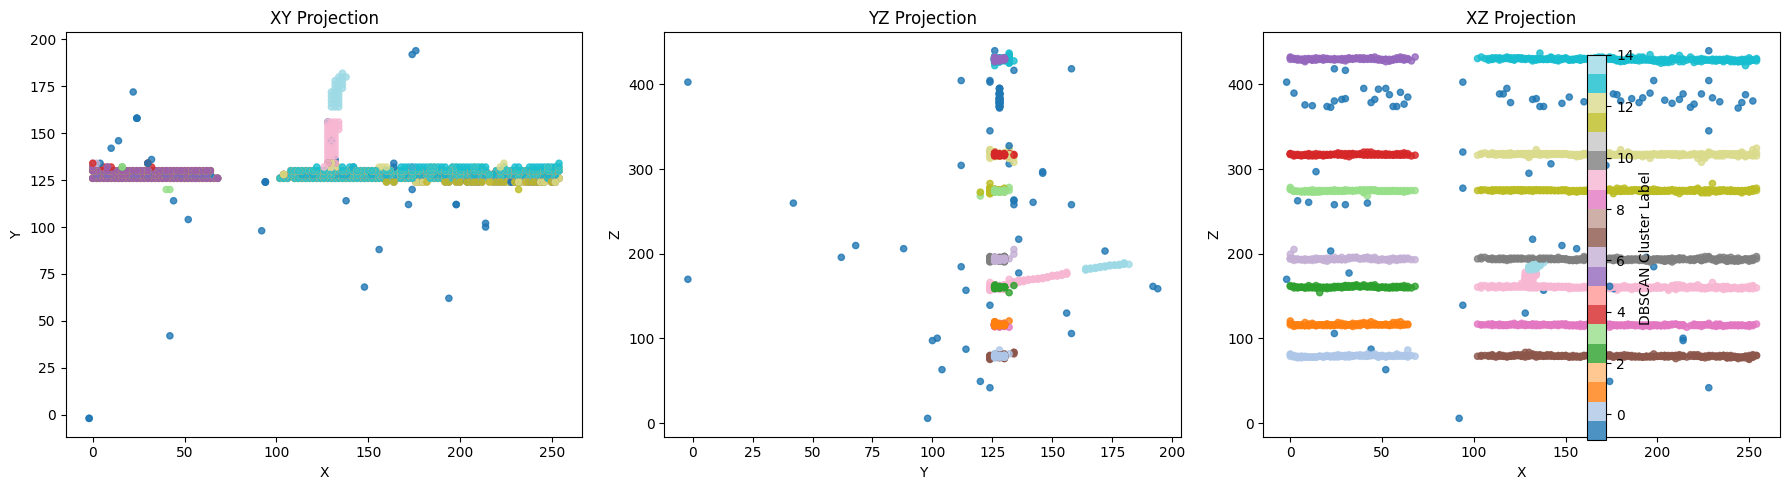

In [30]:
# Create subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# XY projection
sc0 = axs[0].scatter(x, y, c=dbscan_labels, cmap='tab20', s=20, alpha=0.8)
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[0].set_title('XY Projection')

# YZ projection
sc1 = axs[1].scatter(y, z, c=dbscan_labels, cmap='tab20', s=20, alpha=0.8)
axs[1].set_xlabel('Y')
axs[1].set_ylabel('Z')
axs[1].set_title('YZ Projection')

# XZ projection
sc2 = axs[2].scatter(x, z, c=dbscan_labels, cmap='tab20', s=20, alpha=0.8)
axs[2].set_xlabel('X')
axs[2].set_ylabel('Z')
axs[2].set_title('XZ Projection')

# Add a single colorbar for all subplots
cbar = fig.colorbar(sc2, ax=axs, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('DBSCAN Cluster Label')

plt.tight_layout()
plt.show()

In [31]:
from sklearn.mixture import GaussianMixture
# Function to do the GMM Fitting
def fit_gmm_with_bic(data, max_components=10):
    """
    Fit Gaussian Mixture Model using BIC to select optimal components.

    Parameters:
    - data (np.ndarray): Input data array with shape (n_samples, 6) where columns are x, y, z, q, true labels, ransac labels, gmm labels.
    - max_components (int): Maximum number of GMM components to evaluate for BIC score.

    Returns:
    - best_labels (np.ndarray): Labels assigned to each data point for the GMM model with the lowest BIC.
    - best_n_components (int): Number of components in the best GMM model according to BIC.
    """
    # Extract features (first 3 columns: x, y, z, q)
    features = data[:, :3]

    best_bic = np.inf
    best_gmm = None
    best_n_components = 1

    for n_components in range(1, max_components + 1):
        n_samples = features.shape[0]
        if n_components > features.shape[0]:
            break  # Exit loop early if n_components exceeds n_samples
        gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
        gmm.fit(features)
        bic = gmm.bic(features)

        # Check if this model has the lowest BIC
        if bic < best_bic:
            best_bic = bic
            best_gmm = gmm
            best_n_components = n_components

    # Fit the best GMM model and predict labels
    best_labels = best_gmm.predict(features)
    responsibilities = best_gmm.predict_proba(features)

    return best_labels, best_n_components, responsibilities

In [32]:
# Function to do GMM clustering for every dbscan cluster
def hierarchical_clustering_with_responsibilities(data_array, max_components=10):
    """
    Perform DBSCAN clustering and then apply GMM clustering to each DBSCAN cluster,
    computing the responsibility array for all data points.

    Parameters:
    - data_array (np.ndarray): Input data array with at least 3 columns (x, y, z).
    - max_components (int): Maximum number of GMM components to evaluate for BIC.

    Returns:
    - final_labels (np.ndarray): Combined labels for the entire dataset after hierarchical clustering.
    - dbscan_labels (np.ndarray): Labels from the DBSCAN clustering.
    - final_responsibilities (np.ndarray): Responsibility matrix of shape (n_points, total_gmm_clusters).
    """
    # Step 1: Perform DBSCAN clustering
    dbscan_labels, valid_cluster, epsilon_ = dbcluster(data,1,5,20,4,3,6,10)

    if not valid_cluster:
        print("DBSCAN clustering failed.")
        return np.array([-1] * len(data_array)), dbscan_labels, None

    unique_clusters = np.unique(dbscan_labels)
    num_points = len(data_array)

    final_labels = -1 * np.ones(num_points, dtype=int)
    final_responsibilities = -1 * np.ones((num_points, 0))

    current_label_offset = 0

    for cluster_id in unique_clusters:
        if cluster_id == -1:
            continue

        cluster_mask = dbscan_labels == cluster_id
        cluster_data = data_array[cluster_mask]

        gmm_labels, n_comp, responsibilities = fit_gmm_with_bic(cluster_data, max_components=max_components)

        global_gmm_labels = gmm_labels + current_label_offset
        final_labels[cluster_mask] = global_gmm_labels

        new_responsibilities = -1 * np.ones((num_points, n_comp))
        new_responsibilities[cluster_mask, :] = responsibilities
        final_responsibilities = np.hstack((final_responsibilities, new_responsibilities))

        current_label_offset += n_comp

    return final_labels, current_label_offset, final_responsibilities, dbscan_labels


In [33]:
gmm_labels, n_comp, responsibilities, dbscan_labels = hierarchical_clustering_with_responsibilities(data, max_components=10)

USING EPSILON 6.32
USING EPSILON 8.01


C:\Users\alarokia\AppData\Local\Temp\ipykernel_23284\1748249901.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('nipy_spectral', num_clusters)
C:\Users\alarokia\AppData\Local\Temp\ipykernel_23284\1748249901.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\alarokia\AppData\Local\Temp\ipykernel_23284\1748249901.py:60: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


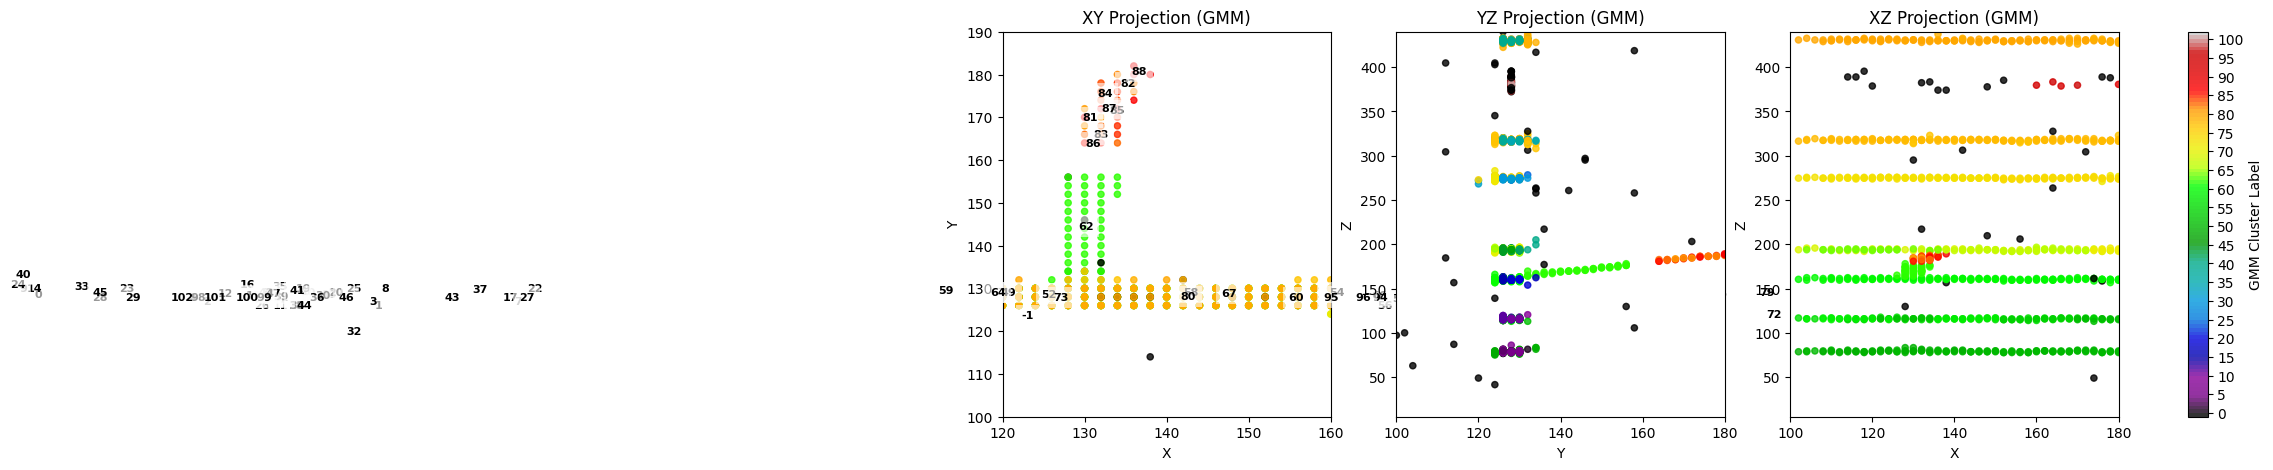

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Load your data
data = np.load('exp_event_34_run_53.npy')
x, y, z = data[:, 0], data[:, 1], data[:, 2]

# Assume gmm_labels is already computed
# gmm_labels, n_comp, responsibilities, dbscan_labels = hierarchical_clustering_with_responsibilities(data, max_components=100)

num_clusters = len(np.unique(gmm_labels))
unique_labels = np.unique(gmm_labels)

# Use spectral colormap
cmap = cm.get_cmap('nipy_spectral', num_clusters)

# Create 2D subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# XY projection
sc0 = axs[0].scatter(x, y, c=gmm_labels, cmap=cmap, s=20, alpha=0.8)
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[0].set_title('XY Projection (GMM)')
axs[0].set_xlim(120, 160)
axs[0].set_ylim(100, 190)

# Annotate cluster labels at cluster centers
for label in unique_labels:
    # Points belonging to this cluster
    cluster_points = data[gmm_labels == label]
    # Compute cluster center
    x_center = np.mean(cluster_points[:, 0])
    y_center = np.mean(cluster_points[:, 1])
    # Place the label near the center
    axs[0].text(x_center, y_center, str(label), fontsize=8, fontweight='bold',
                ha='center', va='center', color='black', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# YZ projection
sc1 = axs[1].scatter(y, z, c=gmm_labels, cmap=cmap, s=20, alpha=0.8)
axs[1].set_xlabel('Y')
axs[1].set_ylabel('Z')
axs[1].set_title('YZ Projection (GMM)')
axs[1].set_xlim(100, 180)
axs[1].set_ylim(min(z), max(z))

# XZ projection
sc2 = axs[2].scatter(x, z, c=gmm_labels, cmap=cmap, s=20, alpha=0.8)
axs[2].set_xlabel('X')
axs[2].set_ylabel('Z')
axs[2].set_title('XZ Projection (GMM)')
axs[2].set_xlim(100, 180)
axs[2].set_ylim(min(z), max(z))

# Discrete colorbar with readable ticks
cbar = fig.colorbar(sc2, ax=axs, ticks=np.arange(0, num_clusters, max(1, num_clusters // 20)))
cbar.set_label('GMM Cluster Label')

plt.tight_layout()
plt.show()
